![](resources/banner.jpg)

# Recopilación de datos

## Marco Geoestadístico del INEGI

Usamos las capas de AGEB (Área Geoestadística Básica) urbana y rural, y localidad amanzanada de la página del INEGI [@inegiMarcoGeoestadistico], a escala Ciudad de México.

De acuerdo al glosario del INEGI [@inegiGlosario]

> **Área geoestadística básica (AGEB)**:
>
> Subdivisión de los municipios o delegaciones que conforman el país, utilizada por vez primera en el X Censo General de Población y Vivienda 1980, que permite la formación de unidades primarias de muestreo y la organización de la información estadística. Tiene tres atributos fundamentales: a) es perfectamente reconocible en el terreno, por estar delimitada por rasgos topográficos identificables y perdurables; b) generalmente es homogénea en cuanto a sus características geográficas, económicas y sociales; c) su extensión es tal que puede ser recorrida por una sola persona. Las AGEB se clasifican en más urbanizadas y menos urbanizadas. Una AGEB más urbanizada puede variar de tamaño entre 20 y 80 manzanas, mientras que una AGEB menos urbanizada puede comprender una o más localidades menores a 100 000 habitantes, dependiendo en ambos casos de la densidad de viviendas.

Las capas se descargan por separado, y fueron renombradas para coincidir con la capa que representan.

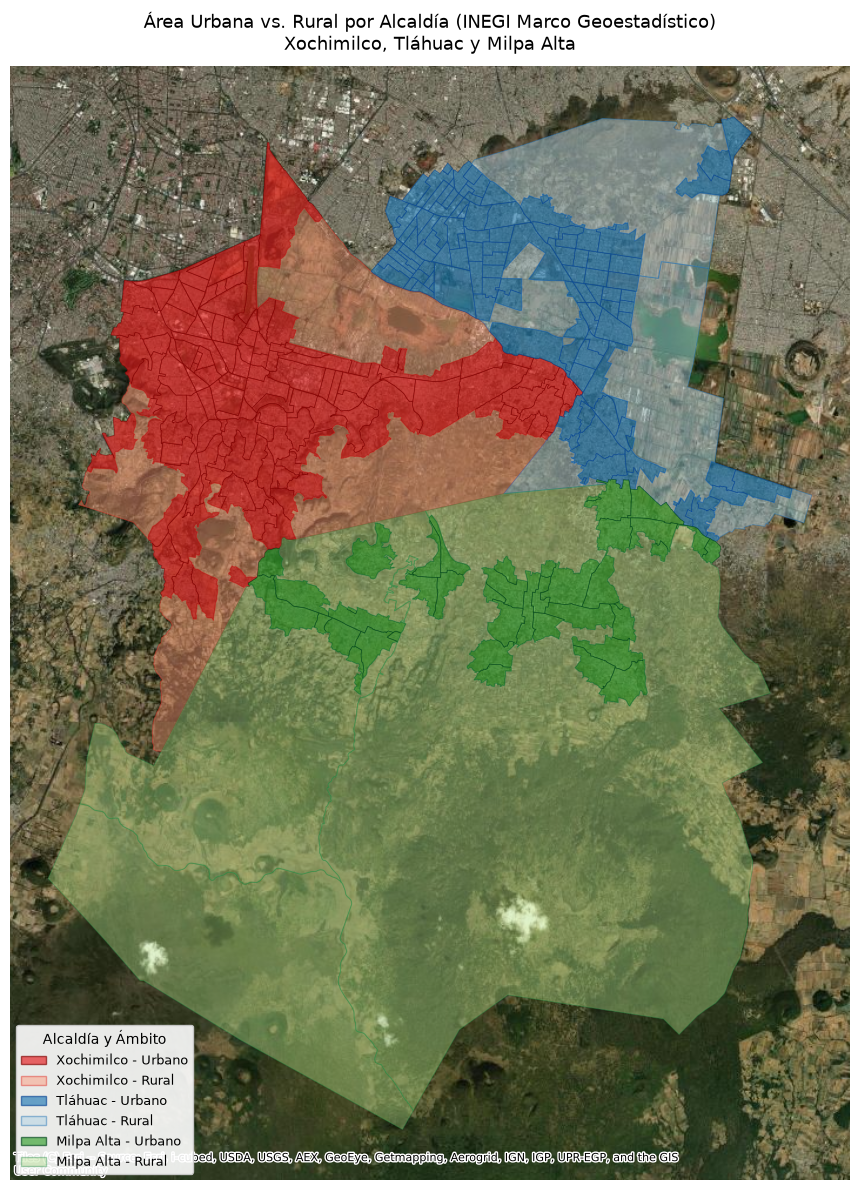

In [1]:
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# 1. Cargar capas de INEGI
MUNICIPIOS = ['009', '011', '013']
NOMBRES_MUN = {'009': 'Milpa Alta', '011': 'Tláhuac', '013': 'Xochimilco'}

ageb_urb = gpd.read_file("../data/ageb_urbano/ageb_urbano.shp")
ageb_rur = gpd.read_file("../data/ageb_rural/ageb_rural.shp")

# 2. Filtrar las 3 alcaldías y proyectar a Web Mercator (EPSG:3857)
urb_sur = ageb_urb[ageb_urb['CVE_MUN'].isin(MUNICIPIOS)].to_crs(epsg=3857).copy()
rur_sur = ageb_rur[ageb_rur['CVE_MUN'].isin(MUNICIPIOS)].to_crs(epsg=3857).copy()

# 3. Asignar etiquetas legibles de alcaldía y tipo
urb_sur['Alcaldia'] = urb_sur['CVE_MUN'].map(NOMBRES_MUN)
urb_sur['Tipo'] = 'Urbano'
urb_sur['Categoria'] = urb_sur['Alcaldia'] + " - Urbano"

rur_sur['Alcaldia'] = rur_sur['CVE_MUN'].map(NOMBRES_MUN)
rur_sur['Tipo'] = 'Rural'
rur_sur['Categoria'] = rur_sur['Alcaldia'] + " - Rural"

# 4. Definición de paleta (Color de relleno, color de borde)
# Se eligen tonos contrastantes pero coherentes por zona
ESTILOS = {
    'Xochimilco - Urbano':   {'fill': '#e41a1c', 'edge': '#7f0000', 'alpha': 0.65},  # Rojo intenso
    'Xochimilco - Rural':    {'fill': '#fc9272', 'edge': '#de2d26', 'alpha': 0.45},  # Salmón / terracota
    'Tláhuac - Urbano':       {'fill': '#1f78b4', 'edge': '#084594', 'alpha': 0.65},  # Azul cobalto
    'Tláhuac - Rural':        {'fill': '#a6cee3', 'edge': '#2171b5', 'alpha': 0.45},  # Azul cielo
    'Milpa Alta - Urbano':    {'fill': '#33a02c', 'edge': '#00441b', 'alpha': 0.65},  # Verde bosque
    'Milpa Alta - Rural':     {'fill': '#b2df8a', 'edge': '#238b45', 'alpha': 0.40},  # Verde pasto
}

# 5. Graficar
fig, ax = plt.subplots(figsize=(13, 12))

# Pintar capas rurales primero (fondo) y luego urbanas (frente)
for cat, estilo in ESTILOS.items():
    if "Rural" in cat:
        sub_gdf = rur_sur[rur_sur['Categoria'] == cat]
        sub_gdf.plot(
            ax=ax,
            facecolor=estilo['fill'],
            edgecolor=estilo['edge'],
            linewidth=0.7,
            alpha=estilo['alpha']
        )
    elif "Urbano" in cat:
        sub_gdf = urb_sur[urb_sur['Categoria'] == cat]
        sub_gdf.plot(
            ax=ax,
            facecolor=estilo['fill'],
            edgecolor=estilo['edge'],
            linewidth=0.5,
            alpha=estilo['alpha']
        )

# 6. Añadir mapa base satelital
try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

# 7. Construir leyenda personalizada
parches_leyenda = [
    mpatches.Patch(
        facecolor=estilo['fill'],
        edgecolor=estilo['edge'],
        label=cat,
        alpha=estilo['alpha']
    )
    for cat, estilo in ESTILOS.items()
]

ax.legend(
    handles=parches_leyenda,
    title="Alcaldía y Ámbito",
    loc="lower left",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=9,
    title_fontsize=10
)

ax.set_title(
    "Área Urbana vs. Rural por Alcaldía (INEGI Marco Geoestadístico)\nXochimilco, Tláhuac y Milpa Alta",
    fontsize=13,
    pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Catálogo de Colonias de la Ciudad de México (Datos Abiertos CDMX)

Es la delimitación geográfica oficial de las unidades territoriales, colonias, barrios y pueblos originarios reconocidos por la administración pública de la Ciudad de México. Mantenida por la Agencia Digital de Innovación Pública (ADIP) [@catColoniasADIP].

A diferencia del Marco Geoestadístico de INEGI (que segmenta en AGEBs numéricas arbitrarias por densidad poblacional para fines censales), esta capa conserva los nombres y las delimitaciones comunitarias, permitiendo acotar a Santiago Tulyehualco y las colonias que lo integran.

In [59]:
import geopandas as gpd

colonias_cdmx = gpd.read_file("../data/mapa_colonias.json")
print(colonias_cdmx.crs)

# Si no tiene CRS definido en el JSON, se lo asignamos primero como EPSG:4326
if colonias_cdmx.crs is None:
    colonias_cdmx = colonias_cdmx.set_crs(epsg=4326)

# Ahora sí lo proyectamos a Web Mercator para contextily
colonias_cdmx = colonias_cdmx.to_crs(epsg=3857)


cols_nombre_colonia = "colonia"
cols_nombre_alcaldia = "alc"

CLAVES_SUR = ["009", "011", "013", "9", "11", "13", "09", "11", "13"]


filtro_sur = colonias_cdmx[cols_nombre_alcaldia].astype(str).str.upper().str.contains(
    "XOCHIMILCO|TL[AÁ]HUAC|MILPA ALTA", regex=True
)

colonias_sur = colonias_cdmx[filtro_sur].copy()
print(f"Total de polígonos cargados: {len(colonias_cdmx)}")
print(f"Unidades territoriales en el suroriente encontradas: {len(colonias_sur)}")

EPSG:4326
Total de polígonos cargados: 1543
Unidades territoriales en el suroriente encontradas: 232


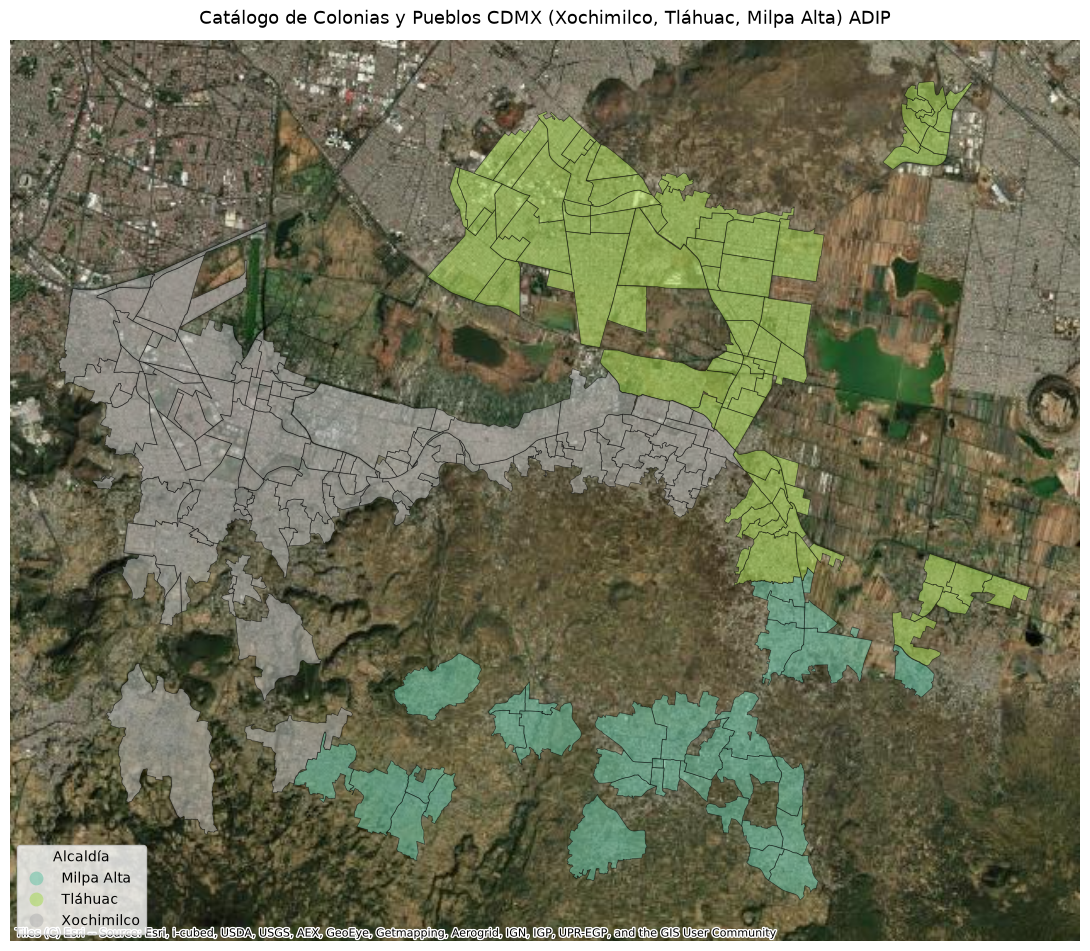

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 10))

colonias_sur.plot(
    column=cols_nombre_alcaldia,
    ax=ax,
    cmap="Set2",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"title": "Alcaldía", "loc": "lower left", "frameon": True},
)

try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

ax.set_title(
    "Catálogo de Colonias y Pueblos CDMX (Xochimilco, Tláhuac, Milpa Alta) ADIP",
    fontsize=13,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Colonias Electorales: IECM 2019

Delimitación territorial de las colonias de la Ciudad de México por el Instituto Electoral de la ciudad de México, versión 2019 [@catColoniasIECM].

Sirve para contrastar las zonas urbanas de nuestro interés respecto a la división del INEGI y al registro del ADIP.

In [61]:
import geopandas as gpd
from IPython.display import HTML

colonias_cdmx_iecm = gpd.read_file("../data/iecm_2019.json")

# Si no tiene CRS definido en el JSON, se lo asignamos primero como EPSG:4326
if colonias_cdmx_iecm.crs is None:
    colonias_cdmx_iecm = colonias_cdmx_iecm.set_crs(epsg=4326)

# Ahora sí lo proyectamos a Web Mercator para contextily
colonias_cdmx_iecm = colonias_cdmx_iecm.to_crs(epsg=3857)

cols_nombre_colonia = "NOMUT"
cols_nombre_alcaldia = "NOMDT"

CLAVES_SUR = ["009", "011", "013", "9", "11", "13", "09", "11", "13"]


filtro_sur_iecm = colonias_cdmx_iecm[cols_nombre_alcaldia].astype(str).str.upper().str.contains(
    "XOCHIMILCO|TL[AÁ]HUAC|MILPA ALTA", regex=True
)

colonias_sur_iecm = colonias_cdmx_iecm[filtro_sur_iecm].copy()
print(f"Total de polígonos cargados: {len(colonias_cdmx_iecm)}")
print(f"Unidades territoriales en el suroriente encontradas: {len(colonias_sur_iecm)}")

Total de polígonos cargados: 1814
Unidades territoriales en el suroriente encontradas: 150


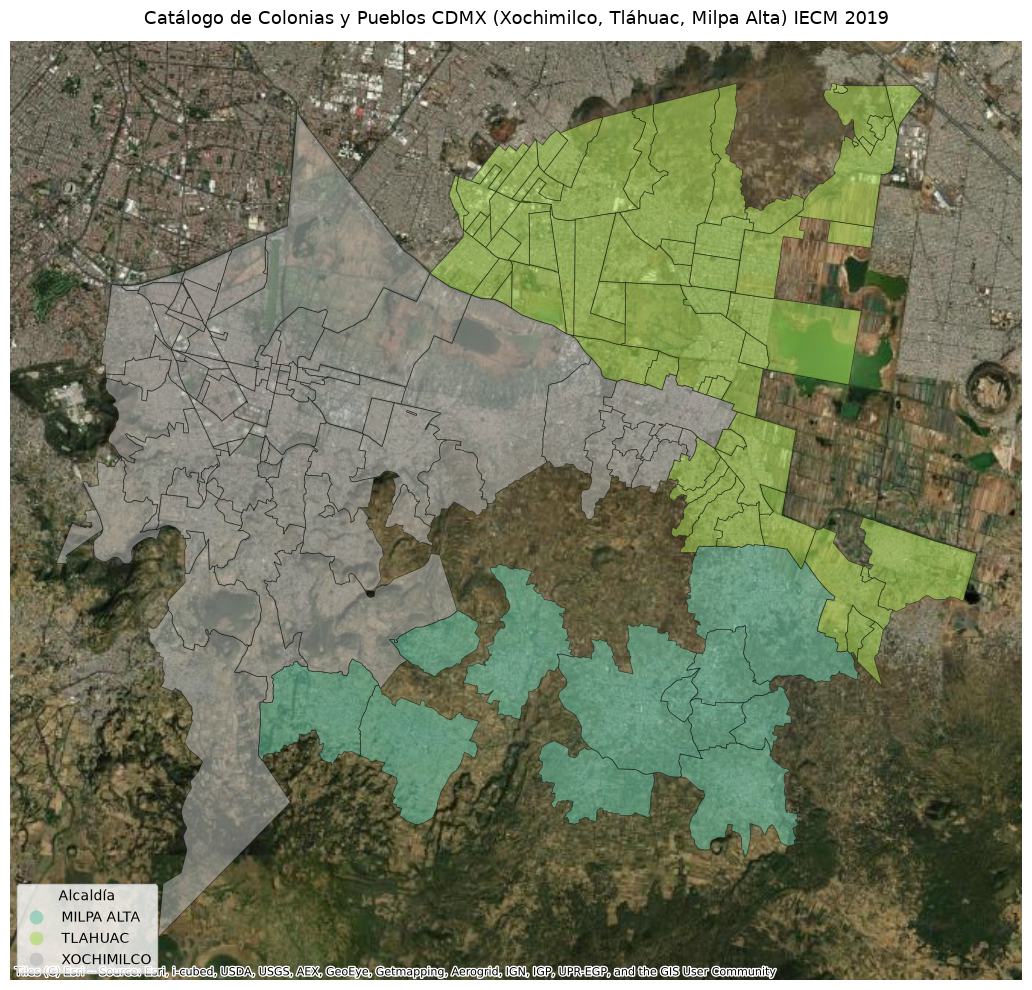

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 10))

colonias_sur_iecm.plot(
    column=cols_nombre_alcaldia,
    ax=ax,
    cmap="Set2",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"title": "Alcaldía", "loc": "lower left", "frameon": True},
)

try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

ax.set_title(
    "Catálogo de Colonias CDMX (Xochimilco, Tláhuac, Milpa Alta) IECM 2019",
    fontsize=13,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Delimitación territorial

La alcaldía Xochimilco [@xocBarrios] cuenta con 14 Pueblos y 17 Barrios originarios. Siendo Santiago Tulyehualco un pueblo originario, conformado por las siguientes colonias:

| Colonias | &nbsp; | &nbsp; |
|---|---|---|
| Calyequita        | Nativitas             | La Esperanza                          |
| La Loma           | Quirino Mendoza       | Los Cerrillos 1.ª, 2.ª y 3.ª sección  |
| Cristo Rey        | San Felipe de Jesús   | Chiquimola                            |
| Casahuates        | Olivar Santa María    | Las Ánimas                            |
| San Sebastián     | San Isidro            | La Lupita                             |
| Las Mesitas       | Santiaguito           | Del Carmen                            |



Entre los datos en línea no hay una representación exacta del área, urbana y rural de nuestro interés por lo que estableceremos un marco de referencia basado en la información presentada en las secciones anteriores.
